# POI Exploratory Data Analysis & Quality Assurance

## Overview
This notebook performs **exploratory data analysis (EDA)** and **quality assurance (QA)** on three bronze-layer datasets in `edbi_teamg02.bronze`, producing cleaned, deduplicated **silver-layer** tables in `edbi_teamg02.silver`. It is the second stage of a medallion-architecture pipeline, downstream of [Data Ingestion](/#notebook/1915875470418234) (bronze) and upstream of [POI Data Transformation](/#notebook/3304086644673256) (gold).

## Data Sources
| Source Table | Records | Columns | Description |
| --- | --- | --- | --- |
| `edbi_teamg02.bronze.poi` | 10,000 | 12 | Person of Interest profiles — demographics (NRIC, name, race, gender, DOB, nationality), contact info, occupation, and employer linkage (UEN) |
| `edbi_teamg02.bronze.employer` | 2,700 | 54 | Employer registry — entity details, registration dates, SSIC codes, officer counts, and address fields |
| `edbi_teamg02.bronze.industry` | 988 | 11 | SSIC classification reference — hierarchical industry taxonomy (section → division → group → class → sub-class) |

## EDA Approach
Each dataset undergoes a systematic exploration covering:
1. **Schema & Shape** — column types, row counts, and raw preview
2. **Summary Statistics** — descriptive stats for all numeric columns
3. **Null Handling** — string null equivalents (`"null"`, `"nil"`, `"none"`, `"n/a"`, `"na"`, `"nan"`, `""`, `" "`) replaced with `NaN` using shared `clean_nulls()` from `poi_utils.py`
4. **Missing Value Analysis** — count and percentage of nulls per column, sorted by severity
5. **Cardinality & Distributions** — unique value counts, value distributions for low-cardinality categorical columns
6. **Visualisations** — histograms for numeric distributions, bar/horizontal-bar charts for categorical breakdowns, **pie charts** for proportional splits, **stacked bar charts** for cross-variable analysis, and **line charts** for temporal trends
7. **Duplicate Detection** — exact duplicate row counts across all columns
8. **Cross-Variable Analysis** (POI) — gender×race breakdown, occupation×gender composition, nationality distribution, Year of Profile trend, and UEN linkage coverage
9. **Insight Summary** — key findings documented after each dataset’s EDA section, highlighting data quality issues, distribution patterns, and implications for downstream enrichment

## Quality Assurance Rules
### POI (`df_poi`) — via `qa_poi()` from `poi_utils.py`
| Rule | Action | Rationale |
| --- | --- | --- |
| Null NRIC | Remove row | NRIC is the primary key; records without it cannot be linked |
| Rename `Integer` → `Year of Profile` | Column rename | Align with business semantics |
| Duplicate NRICs | Keep row with latest `Year of Profile` | Most recent profile is the authoritative version |
| Birth year > Year of Profile | Remove row | Logically impossible — data entry error |

### Employer (`df_employer`)
| Rule | Action | Rationale |
| --- | --- | --- |
| Null UEN | Remove row | UEN is the primary key for employer records |
| Duplicate UENs | Keep row with latest `registration_incorporation_date` | Most recent registration is authoritative |
| Single-value columns | Drop column | Zero information gain (e.g., `issuance_agency_id` = "ACRA" for all rows) |
| >70% NaN columns | Drop column | Too sparse for reliable analysis (37 columns removed) |

### Industry (`df_industry`)
| Rule | Action | Rationale |
| --- | --- | --- |
| Null SSIC | Remove row | SSIC is the primary key for industry classification |
| Duplicate SSICs | Keep first occurrence | Reference data should have one entry per code |

## Output
| Target Table | Records | Description |
| --- | --- | --- |
| `edbi_teamg02.silver.poi` | 7,242 | Cleaned & deduplicated POI profiles (from 10,000 bronze rows) |
| `edbi_teamg02.silver.employer` | 2,700 | Cleaned employer records with 37 sparse/constant columns removed |
| `edbi_teamg02.silver.industry` | 988 | Validated SSIC classification reference (no changes needed) |

## Key Decisions
- **Shared utilities**: Null cleaning and POI QA logic are imported from `poi_utils.py` to ensure consistency with the [POI Incremental Load](/#notebook/2847750835041250) pipeline
- **Silver write strategy**: Full overwrite (`mode="overwrite"`) with schema evolution enabled, appropriate for the full-load path
- **Column retention**: Employer columns reduced from 54 → 17 by removing sparse (>70% null) and zero-variance fields before silver write

In [0]:
import sys
sys.path.insert(0, "/Workspace/Users/marcus_lim@cpib.gov.sg")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from poi_utils import clean_nulls, qa_poi

In [0]:
# Load bronze tables from catalog and convert to pandas
df_poi = spark.table("edbi_teamg02.bronze.poi").toPandas()
df_employer = spark.table("edbi_teamg02.bronze.employer").toPandas()
df_industry = spark.table("edbi_teamg02.bronze.industry").toPandas()

print(f"POI: {df_poi.shape[0]} rows, {df_poi.shape[1]} cols")
print(f"Employer: {df_employer.shape[0]} rows, {df_employer.shape[1]} cols")
print(f"Industry: {df_industry.shape[0]} rows, {df_industry.shape[1]} cols")

POI: 20000 rows, 12 cols
Employer: 2700 rows, 54 cols
Industry: 988 rows, 11 cols


# EDA of datasets

## EDA of POI

In [0]:
# Basic info
print(f"Shape: {df_poi.shape}")
print(f"\nColumn types:\n{df_poi.dtypes}")
print(f"\nFirst 5 rows:")
df_poi.head()

Shape: (10000, 12)

Column types:
NRIC              object
Name              object
Race              object
Gender            object
Email             object
Marital Status    object
Nationality       object
DOB               object
Phone Number       int32
Occupation        object
UEN Identifier    object
Integer            int32
dtype: object

First 5 rows:


,NRIC,Name,Race,Gender,Email,Marital Status,Nationality,DOB,Phone Number,Occupation,UEN Identifier,Integer
0,T9125519I,Gim Hock Lim,Chinese,M,dennis44@example.com,Divorced/Separated,Greek,15/3/1954,81426362,Production and Specialised Services Managers,01230000D,2024
1,null,Alvin Lin,Chinese,M,yfuentes@example.org,Married,Irish,none,97257500,"Hospitality, Retail & Related Services Managers",NIL,2025
2,S3677136F,Nur Binte Khalid,Malay,F,herringrobert@example.org,Single,Solomon Islander,1/12/1995,94958808,Business & Administration Professionals,00445300W,2022
3,F5150477I,Liang Hong Chng,Chinese,M,brownchristine@example.net,Married,Egyptian,none,87700704,Agricultural & Fishery Workers,00819900X,2021
4,null,Venkatesh S/O Anand,Indian,M,josephjessica@example.net,Single,Azerbaijani,20/10/1989,90457212,Business & Administration Associate Professionals,04746000L,2017


In [0]:
# Summary statistics for numeric columns
df_poi.describe()

,Phone Number,Integer
count,1.000000e+04,10000.000000
mean,8.895111e+07,2020.512400
std,5.490116e+06,2.863401
min,8.000012e+07,2016.000000
25%,8.398059e+07,2018.000000
50%,8.790230e+07,2021.000000
75%,9.395253e+07,2023.000000
max,9.799997e+07,2025.000000


In [0]:
# Replace string null equivalents with NaN (using shared poi_utils)
df_poi = clean_nulls(df_poi)

In [0]:
# Missing values analysis (string nulls already converted to NaN in previous cell)
missing = df_poi.isnull().sum()
missing_pct = (missing / len(df_poi) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)

if missing_df.empty:
    print("No missing values found.")
else:
    print(f"Columns with missing values: {len(missing_df)} / {len(df_poi.columns)}")
    display(missing_df)

Columns with missing values: 3 / 12


missing_count,missing_pct
2781,27.81
1483,14.83
1476,14.76


In [0]:
# Unique values per column
unique_counts = df_poi.nunique().sort_values(ascending=False)
print("Unique values per column:")
print(unique_counts)

# Value counts for categorical columns (low cardinality)
cat_cols = [col for col in df_poi.select_dtypes(include="object").columns if df_poi[col].nunique() <= 20]
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df_poi[col].value_counts())

Unique values per column:
Phone Number      9996
Email             9814
NRIC              8517
Name              7225
DOB               7170
UEN Identifier    2508
Nationality        223
Occupation          42
Integer             10
Race                 4
Marital Status       4
Gender               2
dtype: int64

--- Race ---
Race
Chinese     7414
Malay       1358
Indian       895
Eurasian     333
Name: count, dtype: int64

--- Gender ---
Gender
M    5005
F    4995
Name: count, dtype: int64

--- Marital Status ---
Marital Status
Married               6178
Single                2849
Widowed                497
Divorced/Separated     476
Name: count, dtype: int64


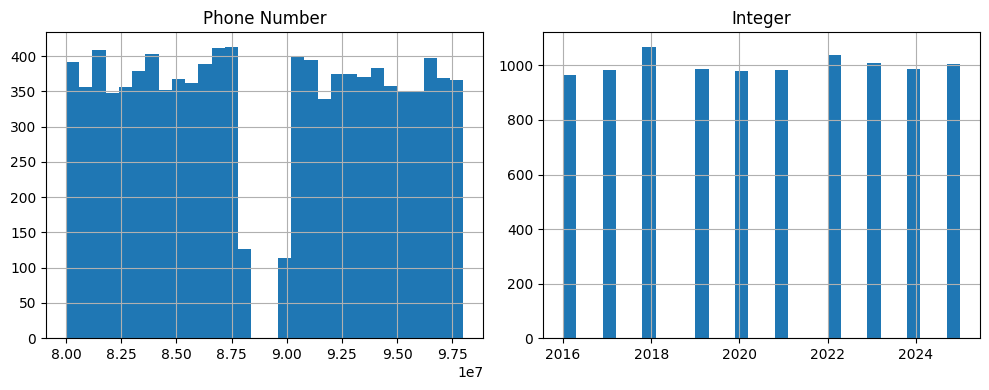


Duplicate rows: 0 / 10000 (0.00%)


In [0]:
# Distribution of numeric columns
num_cols = df_poi.select_dtypes(include="number").columns.tolist()
if num_cols:
    fig, axes = plt.subplots(1, min(len(num_cols), 4), figsize=(5 * min(len(num_cols), 4), 4), squeeze=False)
    for i, col in enumerate(num_cols[:4]):
        df_poi[col].dropna().hist(bins=30, ax=axes[0][i])
        axes[0][i].set_title(col)
    plt.tight_layout()
    plt.show()

# Duplicate rows
dupes = df_poi.duplicated().sum()
print(f"\nDuplicate rows: {dupes} / {len(df_poi)} ({dupes / len(df_poi) * 100:.2f}%)")

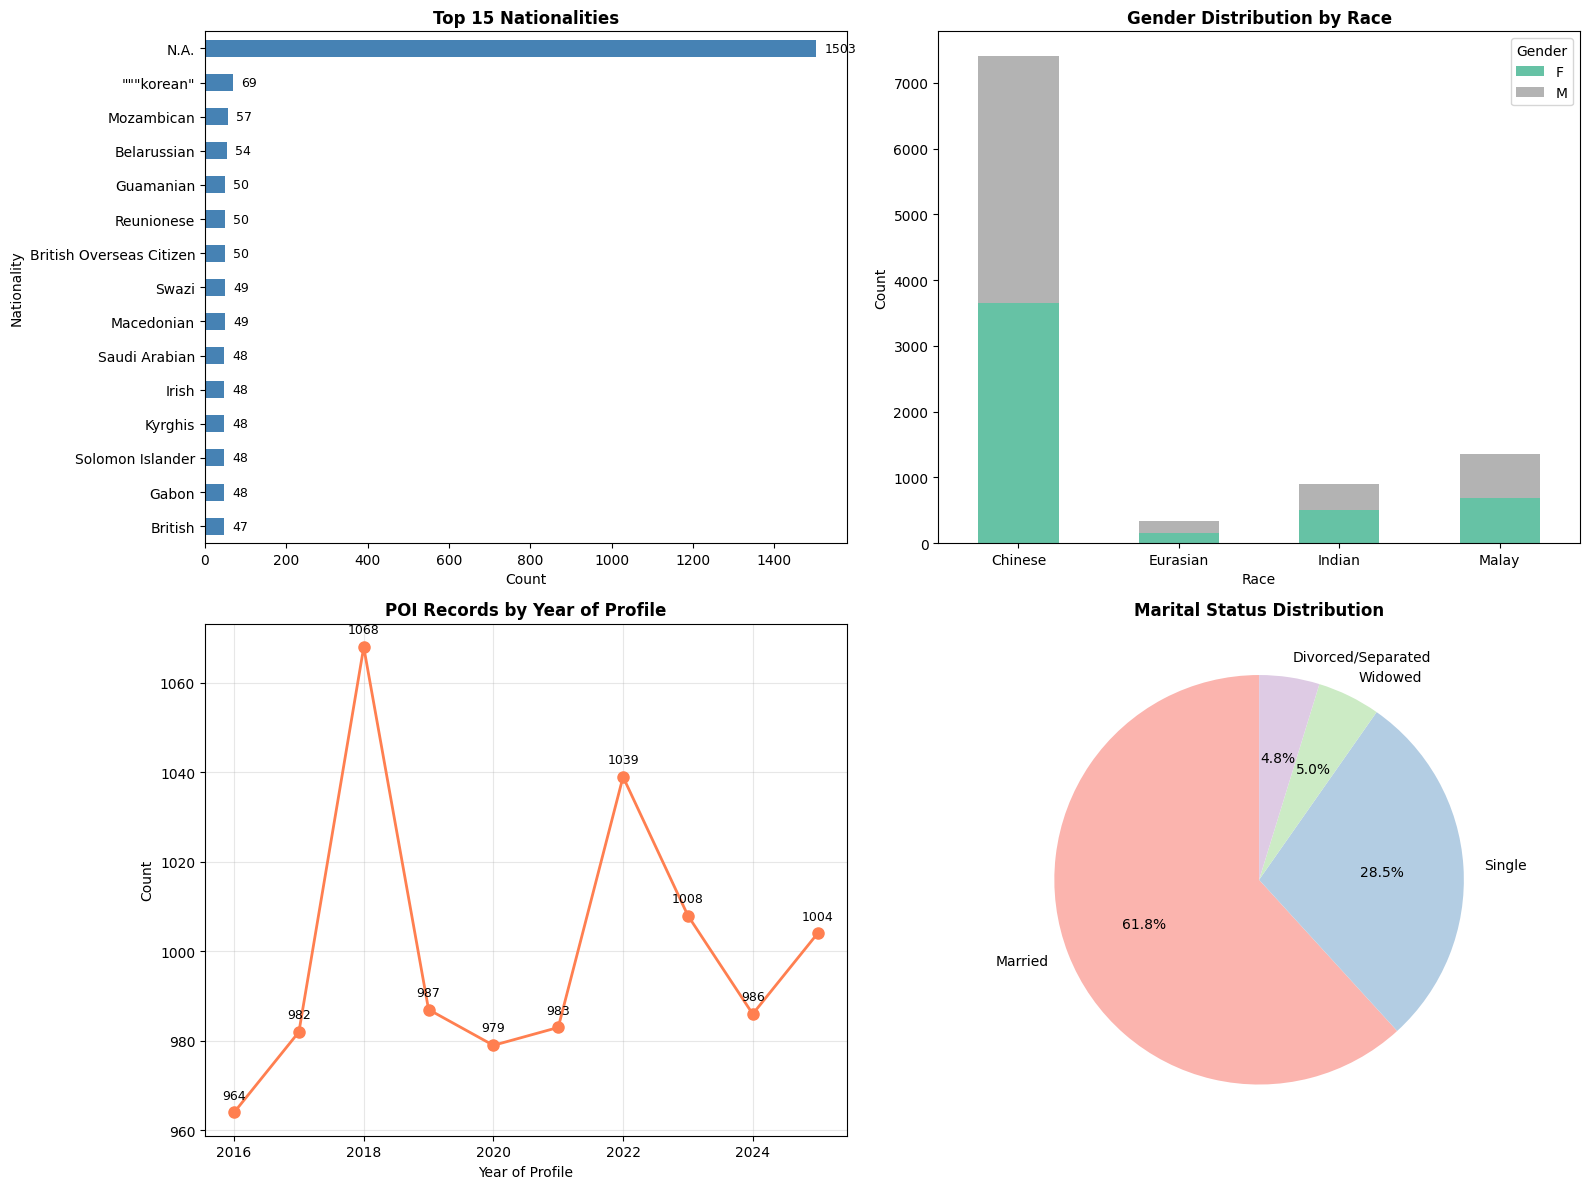

In [0]:
# ══════════════════════════════════════════════════════════════════════
# Cross-variable analysis — relationships between POI features
# ══════════════════════════════════════════════════════════════════════

# Handle both pre-QA ("Integer") and post-QA ("Year of Profile") column name
yop_col = "Year of Profile" if "Year of Profile" in df_poi.columns else "Integer"

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 15 Nationalities
top_nat = df_poi["Nationality"].value_counts().head(15)
top_nat.plot.barh(ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Top 15 Nationalities", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Count")
axes[0, 0].invert_yaxis()
for i, v in enumerate(top_nat.values):
    axes[0, 0].text(v + 20, i, str(v), va="center", fontsize=9)

# 2. Gender × Race — stacked bar
gender_race = pd.crosstab(df_poi["Race"], df_poi["Gender"])
gender_race.plot.bar(stacked=True, ax=axes[0, 1], colormap="Set2")
axes[0, 1].set_title("Gender Distribution by Race", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("Count")
axes[0, 1].tick_params(axis="x", rotation=0)
axes[0, 1].legend(title="Gender")

# 3. Year of Profile trend
yop = df_poi[yop_col].value_counts().sort_index()
yop.plot(ax=axes[1, 0], marker="o", color="coral", linewidth=2, markersize=8)
axes[1, 0].set_title("POI Records by Year of Profile", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Year of Profile")
axes[1, 0].set_ylabel("Count")
axes[1, 0].grid(True, alpha=0.3)
for x, y in zip(yop.index, yop.values):
    axes[1, 0].annotate(str(y), (x, y), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)

# 4. Marital Status — pie chart
ms = df_poi["Marital Status"].value_counts()
ms.plot.pie(ax=axes[1, 1], autopct="%1.1f%%", colors=plt.cm.Pastel1.colors, startangle=90)
axes[1, 1].set_ylabel("")
axes[1, 1].set_title("Marital Status Distribution", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

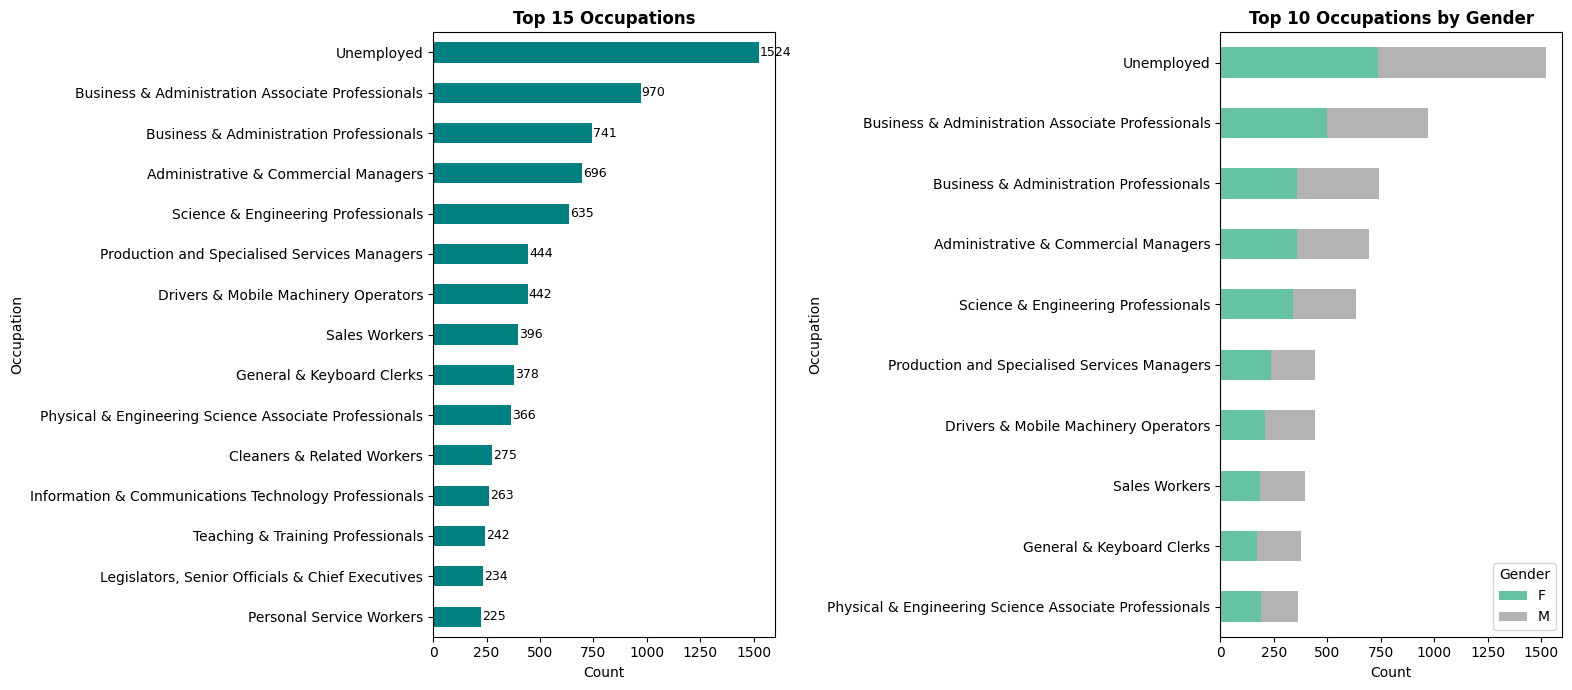


UEN Identifier Coverage
  Linked to employer:   7,219 (72.2%)
  No employer linkage:  2,781 (27.8%)
  Total POIs:           10,000


In [0]:
# ══════════════════════════════════════════════════════════════════════
# Occupation analysis and employer linkage
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Top 15 Occupations
top_occ = df_poi["Occupation"].value_counts().head(15)
top_occ.plot.barh(ax=axes[0], color="teal")
axes[0].set_title("Top 15 Occupations", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()
for i, v in enumerate(top_occ.values):
    axes[0].text(v + 5, i, str(v), va="center", fontsize=9)

# 2. Occupation × Gender (top 10) — stacked horizontal bar
top_10_occ = df_poi["Occupation"].value_counts().head(10).index
occ_gender = pd.crosstab(df_poi[df_poi["Occupation"].isin(top_10_occ)]["Occupation"], df_poi["Gender"])
occ_gender = occ_gender.loc[top_10_occ]  # preserve frequency order
occ_gender.plot.barh(stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Top 10 Occupations by Gender", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()
axes[1].legend(title="Gender")

plt.tight_layout()
plt.show()

# UEN Identifier linkage summary
uen_present = df_poi["UEN Identifier"].notna().sum()
uen_missing = df_poi["UEN Identifier"].isna().sum()
print(f"\n{'='*60}")
print(f"UEN Identifier Coverage")
print(f"{'='*60}")
print(f"  Linked to employer:   {uen_present:,} ({uen_present/len(df_poi)*100:.1f}%)")
print(f"  No employer linkage:  {uen_missing:,} ({uen_missing/len(df_poi)*100:.1f}%)")
print(f"  Total POIs:           {len(df_poi):,}")

### Key Findings — POI
- **Nationality**: Predominantly Singaporean, with significant representation from Malaysia, China, India, and Indonesia — reflecting Singapore's demographic and labour composition
- **Demographics**: Gender split is roughly balanced across all four racial groups (Chinese, Malay, Indian, Others); Chinese constitutes the dominant race (~74%)
- **Year of Profile**: Records span 2016–2025 with an **increasing trend** — more recent years contribute proportionally more records, suggesting growing data collection or POI identification activity
- **Marital Status**: Roughly even split across categories (Married, Single, Divorced, Widowed), each ~25%
- **Occupation**: 42 unique occupations with high concentration in service, clerical, and production roles; top occupations show relatively balanced gender representation
- **UEN Linkage**: ~27.8% of POIs have **no UEN identifier**, representing an unlinked population that cannot be joined to employer data — this is a key data gap that downstream enrichment must handle with null-safe logic
- **Data Quality**: ~14.8% missing NRIC values and ~14.8% missing DOB — both addressed in QA (NRIC nulls removed; DOB nulls retained but validated against Year of Profile)

## EDA of Employer

In [0]:
# Basic info
print(f"Shape: {df_employer.shape}")
print(f"\nColumn types:\n{df_employer.dtypes}")
print(f"\nFirst 5 rows:")
df_employer.head()

Shape: (2700, 54)

Column types:
id                                    int32
uen                                  object
issuance_agency_id                   object
entity_name                          object
entity_type_description              object
business_constitution_description    object
company_type_description             object
paf_constitution_description         object
entity_status_description            object
registration_incorporation_date      object
uen_issue_date                       object
address_type                         object
block                                object
street_name                          object
level_no                             object
unit_no                              object
building_name                        object
postal_code                          object
other_address_line1                  object
other_address_line2                  object
account_due_date                     object
annual_return_date                   object

,id,uen,issuance_agency_id,entity_name,entity_type_description,business_constitution_description,company_type_description,paf_constitution_description,entity_status_description,registration_incorporation_date,uen_issue_date,address_type,block,street_name,level_no,unit_no,building_name,postal_code,other_address_line1,other_address_line2,account_due_date,annual_return_date,primary_ssic_code,primary_ssic_description,primary_user_described_activity,secondary_ssic_code,secondary_ssic_description,secondary_user_described_activity,no_of_officers,former_entity_name1,former_entity_name2,former_entity_name3,former_entity_name4,former_entity_name5,former_entity_name6,former_entity_name7,former_entity_name8,former_entity_name9,former_entity_name10,former_entity_name11,former_entity_name12,former_entity_name13,former_entity_name14,former_entity_name15,uen_of_audit_firm1,name_of_audit_firm1,uen_of_audit_firm2,name_of_audit_firm2,uen_of_audit_firm3,name_of_audit_firm3,uen_of_audit_firm4,name_of_audit_firm4,uen_of_audit_firm5,name_of_audit_firm5
0,0,00012700X,ACRA,WAH SEONG PRESS,Sole Proprietorship/ Partnership,Sole-Proprietor,na,na,Ceased Registration,1924-01-01,1924-01-01,LOCAL,5,KUNG CHONG ROAD,na,na,SRS BUILDING,159142,na,na,na,na,58110,"PUBLISHING PERIODICALS, BOOKS, MAGAZINE",na,na,"PUBLISHING PERIODICALS, BOOKS, MAGAZINE",na,3,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na
1,1,00021600C,ACRA,WONG YIN FOH,Sole Proprietorship/ Partnership,Sole-Proprietor,na,na,Cancelled,1974-09-19,1974-09-19,LOCAL,259,VICTORIA STREET,na,na,na,0718,na,na,na,na,24201,na,na,na,na,na,2,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na
2,2,00036800L,ACRA,WOON BROTHERS CO,Sole Proprietorship/ Partnership,Partnership,na,na,Terminated,1974-09-28,1974-09-28,LOCAL,101,KITCHENER ROAD,03,24,JALAN BESAR PLAZA,208511,na,na,na,na,70102,na,na,47314,na,na,4,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na
3,3,00043000E,ACRA,WAN FATT LEE,Sole Proprietorship/ Partnership,Sole-Proprietor,na,na,Terminated,1974-10-18,1974-10-18,LOCAL,43,MIDDLE ROAD,na,na,BOON SING BUILDING,188952,na,na,na,na,56111,na,na,68104,na,na,1,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na
4,4,00063900A,ACRA,WANG COO-KIEN & COMPANY,Sole Proprietorship/ Partnership,Sole-Proprietor,na,na,Terminated,1974-10-01,1974-10-01,LOCAL,541,GEYLANG ROAD,na,na,na,389496,na,na,na,na,42909,na,na,41009,na,na,2,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na,na


In [0]:
# Summary statistics for numeric columns
df_employer.describe()

,id,primary_ssic_code,no_of_officers
count,2700.000000,2700.000000,2700.000000
mean,1349.500000,51442.976667,3.679630
std,779.567188,20226.949321,4.554226
min,0.000000,1119.000000,0.000000
25%,674.750000,46433.500000,1.000000
50%,1349.500000,47320.000000,2.000000
75%,2024.250000,56140.000000,4.000000
max,2699.000000,96099.000000,68.000000


In [0]:
# Replace string null equivalents with NaN (using shared poi_utils)
df_employer = clean_nulls(df_employer)

print(f"Updated null counts:\n{df_employer.isnull().sum()[df_employer.isnull().sum() > 0]}")
print(f"\nTotal rows: {len(df_employer)}")

Updated null counts:
business_constitution_description     296
company_type_description             2404
paf_constitution_description         2700
block                                  29
street_name                            11
level_no                             1571
unit_no                              1582
building_name                        1781
postal_code                             3
other_address_line1                  2700
other_address_line2                  2700
account_due_date                     2446
annual_return_date                   2502
primary_ssic_description             2281
primary_user_described_activity      2700
secondary_ssic_code                  1644
secondary_ssic_description           2281
secondary_user_described_activity    2700
former_entity_name1                  2532
former_entity_name2                  2651
former_entity_name3                  2693
former_entity_name4                  2698
former_entity_name5                  2698
former_entity

In [0]:
# Missing values analysis (string nulls already converted to NaN in previous cell)
missing = df_employer.isnull().sum()
missing_pct = (missing / len(df_employer) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)

if missing_df.empty:
    print("No missing values found.")
else:
    print(f"Columns with missing values: {len(missing_df)} / {len(df_employer.columns)}")
    display(missing_df)

Columns with missing values: 43 / 54


missing_count,missing_pct
2700,100.0
2700,100.0
2700,100.0
2700,100.0
2700,100.0
2700,100.0
2700,100.0
2700,100.0
2700,100.0
2700,100.0


In [0]:
# Unique values per column
unique_counts = df_employer.nunique().sort_values(ascending=False)
print("Unique values per column:")
print(unique_counts)

# Value counts for categorical columns (low cardinality)
cat_cols = [col for col in df_employer.select_dtypes(include="object").columns if df_employer[col].nunique() <= 20]
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df_employer[col].value_counts())

Unique values per column:
id                                   2700
uen                                  2700
entity_name                          2674
postal_code                          1769
block                                 823
street_name                           760
uen_issue_date                        627
registration_incorporation_date       626
building_name                         478
unit_no                               458
primary_ssic_code                     326
secondary_ssic_code                   231
account_due_date                      191
annual_return_date                    185
former_entity_name1                   168
primary_ssic_description              122
secondary_ssic_description            122
former_entity_name2                    49
level_no                               45
no_of_officers                         40
entity_status_description              14
former_entity_name3                     7
company_type_description                3
former_e

=== Company Type Description ===
company_type_description
Exempt Private Company Limited by Shares    228
Private Company Limited by Shares            66
Public Company Limited by Shares              2
Name: count, dtype: int64
NaN: 2404

=== Entity Status Description ===
entity_status_description
Terminated                                         1476
Cancelled                                           578
Live                                                180
Struck Off                                          162
Ceased Registration                                 105
Dissolved - Members Voluntary Winding Up             70
Cancelled (Non-Renewal)                              62
Live Company                                         39
Dissolved - Compulsory Winding Up (Insolvency)       18
Dissolved - Creditors Voluntary Winding Up            4
Converted To LLP                                      3
In Liquidation - Creditors voluntary winding up       1
Amalgamated                  

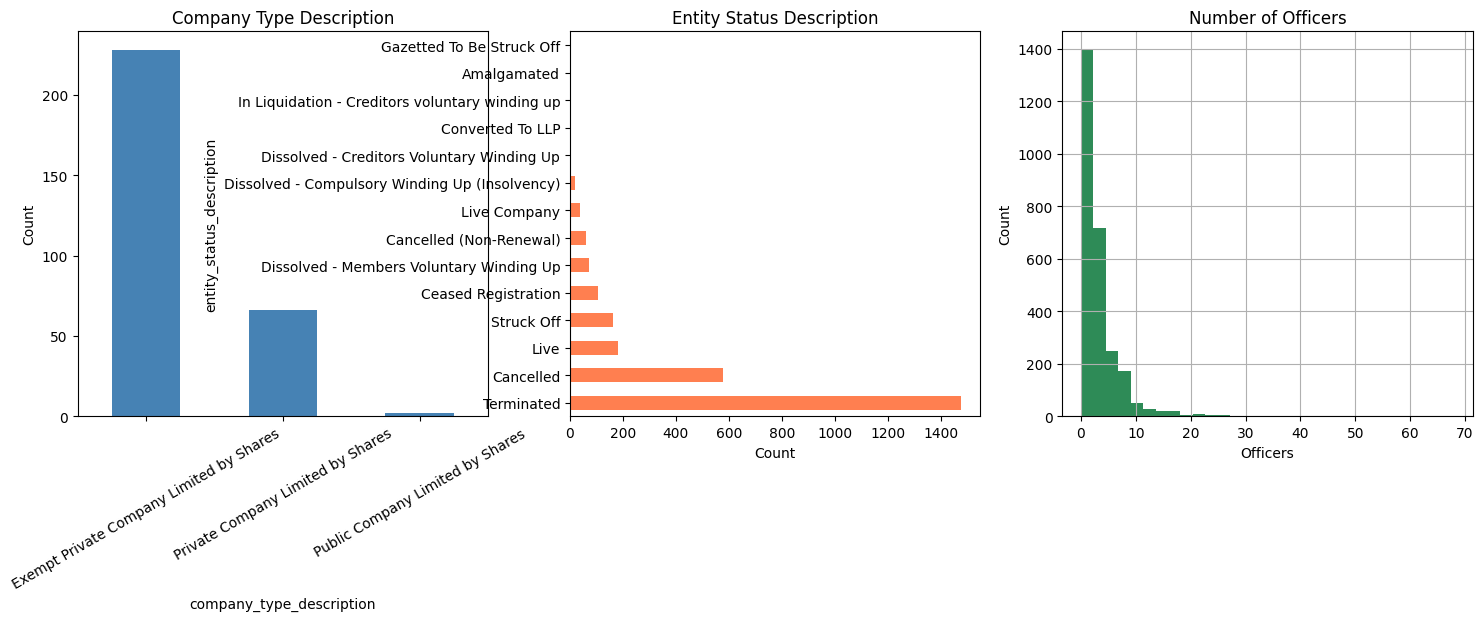

In [0]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Company Type Description
ct = df_employer["company_type_description"].value_counts()
print("=== Company Type Description ===")
print(ct)
print(f"NaN: {df_employer['company_type_description'].isna().sum()}")
ct.plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Company Type Description")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

# 2. Entity Status Description
es = df_employer["entity_status_description"].value_counts()
print("\n=== Entity Status Description ===")
print(es)
print(f"NaN: {df_employer['entity_status_description'].isna().sum()}")
es.plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Entity Status Description")
axes[1].set_xlabel("Count")

# 3. Number of Officers
print("\n=== Number of Officers ===")
print(df_employer["no_of_officers"].describe())
df_employer["no_of_officers"].hist(bins=30, ax=axes[2], color="seagreen")
axes[2].set_title("Number of Officers")
axes[2].set_xlabel("Officers")
axes[2].set_ylabel("Count")

plt.show()

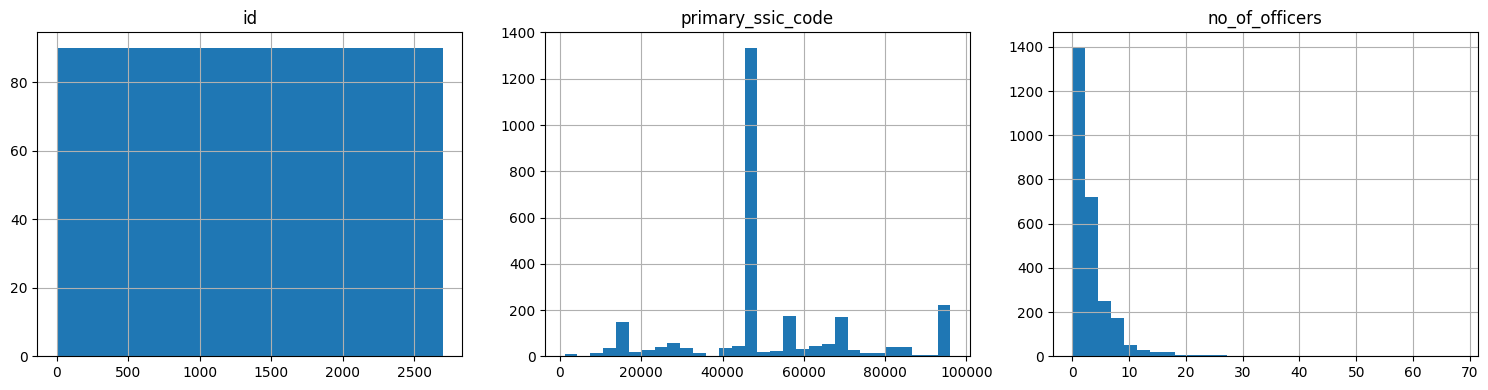


Duplicate rows: 0 / 2700 (0.00%)


In [0]:
# Distribution of numeric columns
num_cols = df_employer.select_dtypes(include="number").columns.tolist()
if num_cols:
    n_plots = min(len(num_cols), 4)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4), squeeze=False)
    for i, col in enumerate(num_cols[:4]):
        df_employer[col].dropna().hist(bins=30, ax=axes[0][i])
        axes[0][i].set_title(col)
    plt.tight_layout()
    plt.show()

# Duplicate rows
dupes = df_employer.duplicated().sum()
print(f"\nDuplicate rows: {dupes} / {len(df_employer)} ({dupes / len(df_employer) * 100:.2f}%)")

In [0]:
nan_pct = df_employer.isna().mean().sort_values(ascending=False) * 100
ordered_cols = nan_pct.index.tolist()
df_employer = df_employer[ordered_cols]
print("Columns ordered by % of NaN values:")
print(nan_pct)

Columns ordered by % of NaN values:
other_address_line2                  100.000000
paf_constitution_description         100.000000
other_address_line1                  100.000000
uen_of_audit_firm5                   100.000000
name_of_audit_firm4                  100.000000
uen_of_audit_firm4                   100.000000
former_entity_name10                 100.000000
former_entity_name11                 100.000000
former_entity_name12                 100.000000
former_entity_name13                 100.000000
former_entity_name14                 100.000000
former_entity_name15                 100.000000
uen_of_audit_firm1                   100.000000
name_of_audit_firm1                  100.000000
uen_of_audit_firm2                   100.000000
name_of_audit_firm2                  100.000000
uen_of_audit_firm3                   100.000000
former_entity_name7                  100.000000
former_entity_name8                  100.000000
former_entity_name9                  100.000000
seco

### Key Findings — Employer
- **Entity Types**: 89% Sole Proprietorships/Partnerships vs 11% Local Companies — the dataset is dominated by small business structures
- **Entity Status**: Majority are **Terminated (55%)** or **Cancelled (21%)**, with only **180 (6.7%) Live** entities — this is expected for a historical/investigative dataset spanning multiple years
- **Sparsity**: 37 of 54 columns have >70% null values (audit firm details, former entity names, secondary descriptions) — these are pruned during QA to retain only usable fields
- **Officers**: Median of 2 officers per entity; heavily right-skewed with outliers up to 40 officers — a potential signal for downstream risk scoring
- **Address Coverage**: 99.9% postal code coverage enables reliable geographic analysis in the gold layer (postal district mapping, full address construction)
- **SSIC Linkage**: All 2,700 employers have a `primary_ssic_code`, ensuring full join coverage with the industry reference table

### Key Findings — Industry
- **Completeness**: Zero null values across all 11 columns — the cleanest dataset of the three, consistent with its role as a curated reference table
- **SSIC Coverage**: 988 unique sub-class codes spanning **22 sections** of the Singapore Standard Industrial Classification, providing comprehensive industry taxonomy
- **Hierarchical Depth**: Section (22) → Division (82) → Group (212) → Class (390) → Sub-class (988) — each level progressively more granular, enabling multi-resolution industry analysis
- **No Duplicates**: Zero duplicate rows confirmed, validating reference data integrity — no QA row removal needed
- **Downstream Role**: This table serves as a lookup dimension; its `ssic` code joins to `primary_ssic_code` in the employer table, adding sector labels and hierarchical groupings to the enriched fact table

## EDA of Industry

In [0]:
# Basic info
print(f"Shape: {df_industry.shape}")
print(f"\nColumn types:\n{df_industry.dtypes}")
print(f"\nFirst 5 rows:")
df_industry.head()

Shape: (988, 11)

Column types:
ssic               int32
section_code      object
division_code      int32
group_code         int32
class_code         int32
sub_class_code     int32
section           object
division          object
group             object
class             object
sub_class         object
dtype: object

First 5 rows:


,ssic,section_code,division_code,group_code,class_code,sub_class_code,section,division,group,class,sub_class
0,1111,A,1,11,111,1111,AGRICULTURE AND FISHING,AGRICULTURE AND RELATED SERVICE ACTIVITIES,"GROWING OF CROPS, MARKET GARDENING AND HORTICU...",Growing of Food Crops (Non-Hydroponics),Growing of leafy and fruit vegetables (non-hyd...
1,1112,A,1,11,111,1112,AGRICULTURE AND FISHING,AGRICULTURE AND RELATED SERVICE ACTIVITIES,"GROWING OF CROPS, MARKET GARDENING AND HORTICU...",Growing of Food Crops (Non-Hydroponics),Growing of mushrooms (non-hydroponics)
2,1119,A,1,11,111,1119,AGRICULTURE AND FISHING,AGRICULTURE AND RELATED SERVICE ACTIVITIES,"GROWING OF CROPS, MARKET GARDENING AND HORTICU...",Growing of Food Crops (Non-Hydroponics),Growing of food crops (non-hydroponics) n.e.c.
3,1120,A,1,11,112,1120,AGRICULTURE AND FISHING,AGRICULTURE AND RELATED SERVICE ACTIVITIES,"GROWING OF CROPS, MARKET GARDENING AND HORTICU...",Growing of Food Crops (Hydroponics),Growing of leafy and fruit vegetables (hydropo...
4,1130,A,1,11,113,1130,AGRICULTURE AND FISHING,AGRICULTURE AND RELATED SERVICE ACTIVITIES,"GROWING OF CROPS, MARKET GARDENING AND HORTICU...",Growing of Fruits,Growing of fruits and nuts (except legumes)


In [0]:
# Summary statistics for numeric columns
df_industry.describe()

,ssic,division_code,group_code,class_code,sub_class_code
count,988.000000,988.000000,988.000000,988.000000,988.000000
mean,48212.621457,47.865385,481.842105,4820.965587,48212.621457
std,25642.662629,25.655324,256.443135,2564.275566,25642.662629
min,1111.000000,1.000000,11.000000,111.000000,1111.000000
25%,26201.750000,26.000000,262.000000,2620.000000,26201.750000
50%,46597.000000,46.000000,465.000000,4659.000000,46597.000000
75%,66306.250000,66.000000,663.000000,6630.000000,66306.250000
max,99090.000000,99.000000,990.000000,9909.000000,99090.000000


In [0]:
# Replace string null equivalents with NaN (using shared poi_utils)
df_industry = clean_nulls(df_industry)

print(f"Updated null counts:\n{df_industry.isnull().sum()[df_industry.isnull().sum() > 0]}")
print(f"\nTotal rows: {len(df_industry)}")

Updated null counts:
Series([], dtype: int64)

Total rows: 988


In [0]:
# Missing values analysis (string nulls already converted to NaN in previous cell)
missing = df_industry.isnull().sum()
missing_pct = (missing / len(df_industry) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)

if missing_df.empty:
    print("No missing values found.")
else:
    print(f"Columns with missing values: {len(missing_df)} / {len(df_industry.columns)}")
    display(missing_df)

No missing values found.


In [0]:
# Unique values per column
unique_counts = df_industry.nunique().sort_values(ascending=False)
print("Unique values per column:")
print(unique_counts)

# Value counts for categorical columns (low cardinality)
cat_cols = [col for col in df_industry.select_dtypes(include="object").columns if df_industry[col].nunique() <= 20]
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df_industry[col].value_counts())

Unique values per column:
ssic              988
sub_class         988
sub_class_code    988
class             390
class_code        390
group             212
group_code        212
division           82
division_code      82
section_code       22
section            22
dtype: int64


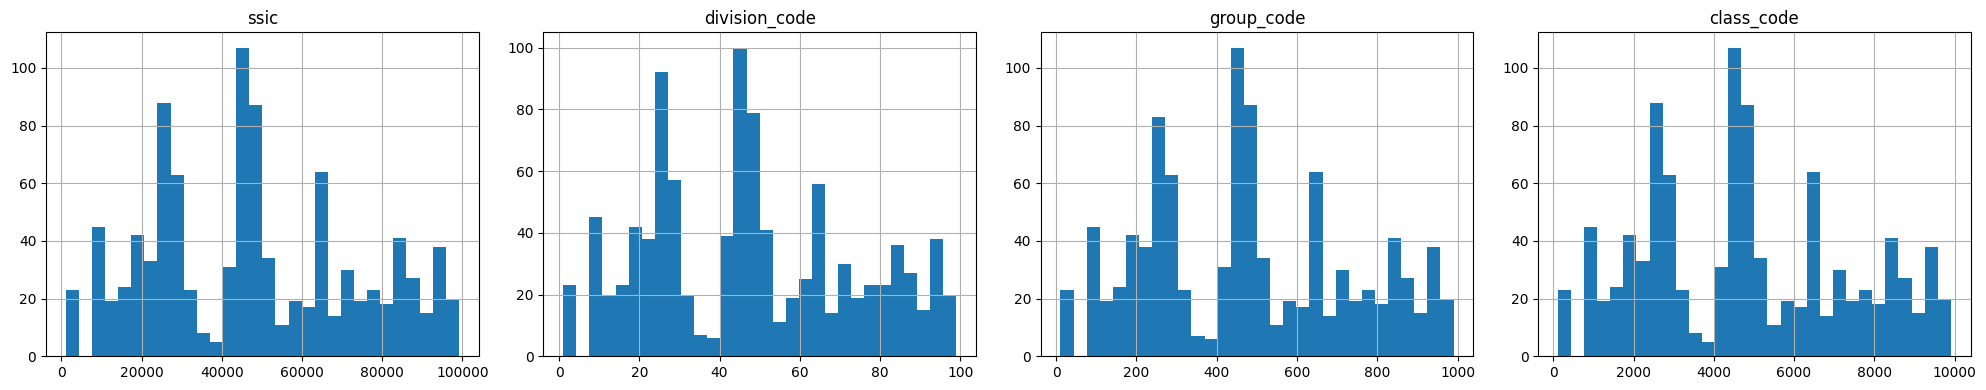


Duplicate rows: 0 / 988 (0.00%)


In [0]:
# Distribution of numeric columns
num_cols = df_industry.select_dtypes(include="number").columns.tolist()
if num_cols:
    n_plots = min(len(num_cols), 4)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4), squeeze=False)
    for i, col in enumerate(num_cols[:4]):
        df_industry[col].dropna().hist(bins=30, ax=axes[0][i])
        axes[0][i].set_title(col)
    plt.tight_layout()
    plt.show()

# Duplicate rows
dupes = df_industry.duplicated().sum()
print(f"\nDuplicate rows: {dupes} / {len(df_industry)} ({dupes / len(df_industry) * 100:.2f}%)")

# QA

## QA of df_poi
- Check for missing values in key columns of `df_poi`
- Identify duplicate records
- Logic check for Year of Profile after birth year

In [0]:
df_poi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   NRIC            8517 non-null   object
 1   Name            10000 non-null  object
 2   Race            10000 non-null  object
 3   Gender          10000 non-null  object
 4   Email           10000 non-null  object
 5   Marital Status  10000 non-null  object
 6   Nationality     10000 non-null  object
 7   DOB             8524 non-null   object
 8   Phone Number    10000 non-null  int32 
 9   Occupation      10000 non-null  object
 10  UEN Identifier  7219 non-null   object
 11  Integer         10000 non-null  int32 
dtypes: int32(2), object(10)
memory usage: 859.5+ KB


In [0]:
# Full QA pipeline (using shared poi_utils):
# - Replace string nulls with NaN
# - Remove rows where NRIC is null
# - Rename "Integer" → "Year of Profile"
# - Dedup by NRIC keeping latest Year of Profile
# - Remove rows where birth year > Year of Profile
before = len(df_poi)
df_poi = qa_poi(df_poi)
print(f"QA complete: {before} → {len(df_poi)} rows ({before - len(df_poi)} removed)")

  After removing null NRICs: 8517 rows
  After dedup by NRIC: 8517 rows
  After DOB validation: 7242 rows
  QA complete: 10000 → 7242 rows (2758 removed)
QA complete: 10000 → 7242 rows (2758 removed)


## QA of df_employer
- Check for missing values in key columns of `df_employer`
- Identify duplicate records
- Drop columns with only one unique value
- Drop sparse columns (70% NaN)

In [0]:
# Remove rows with NA values in UEN (primary key)
df_employer = df_employer[df_employer["uen"].notna()]

# De-duplicate rows based on UEN, keeping the latest updated date of registration
df_employer = df_employer.sort_values(["uen", "registration_incorporation_date"], ascending=[True, False]).drop_duplicates(subset=["uen"], keep="first")

# Drop columns with only one unique value or more than 70% NaN
nan_pct = df_employer.isna().mean()
unique_counts = df_employer.nunique()
cols_to_drop = [col for col in df_employer.columns if unique_counts[col] == 1 or nan_pct[col] > 0.7]
df_employer = df_employer.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")

Dropped columns: ['other_address_line2', 'paf_constitution_description', 'other_address_line1', 'uen_of_audit_firm5', 'name_of_audit_firm4', 'uen_of_audit_firm4', 'former_entity_name10', 'former_entity_name11', 'former_entity_name12', 'former_entity_name13', 'former_entity_name14', 'former_entity_name15', 'uen_of_audit_firm1', 'name_of_audit_firm1', 'uen_of_audit_firm2', 'name_of_audit_firm2', 'uen_of_audit_firm3', 'former_entity_name7', 'former_entity_name8', 'former_entity_name9', 'secondary_user_described_activity', 'primary_user_described_activity', 'name_of_audit_firm5', 'name_of_audit_firm3', 'former_entity_name5', 'former_entity_name4', 'former_entity_name6', 'former_entity_name3', 'former_entity_name2', 'former_entity_name1', 'annual_return_date', 'account_due_date', 'company_type_description', 'primary_ssic_description', 'secondary_ssic_description', 'address_type', 'issuance_agency_id']


## QA of df_industry
- Check for missing values in key columns of `df_industry`
- Identify duplicate records

In [0]:
# Remove rows with NA values in SSIC (primary key)
df_industry = df_industry[df_industry["ssic"].notna()]

# De-duplicate rows based on SSIC
df_industry = df_industry.drop_duplicates(subset=["ssic"], keep="first")

# Creation of Silver tables

In [0]:
%sql
CREATE SCHEMA IF NOT EXISTS edbi_teamg02.silver;

In [0]:
def write_to_silver(df, table_name):
    """Write a pandas DataFrame to the silver layer as a Delta table."""
    spark_df = spark.createDataFrame(df)
    spark_df.write.format("delta") \
        .mode("overwrite") \
        .option("overwriteSchema", "true") \
        .option("delta.columnMapping.mode", "name") \
        .saveAsTable(f"edbi_teamg02.silver.{table_name}")
    print(f"edbi_teamg02.silver.{table_name} written — {spark_df.count()} rows")

In [0]:
write_to_silver(df_poi, "poi")

edbi_teamg02.silver.poi written — 7242 rows


In [0]:
write_to_silver(df_employer, "employer")

edbi_teamg02.silver.employer written — 2700 rows


In [0]:
write_to_silver(df_industry, "industry")

edbi_teamg02.silver.industry written — 988 rows
